# PyTorch로 선형회귀 학습시키기 — Autograd 들여다보기

이 노트북은 [홍랩 AI(HongLab AI)](https://www.honglab.ai/) 홍정모 님의
[파트1. 딥러닝 첫걸음](https://www.honglab.ai/courses/aipt1) 강의를 공부하면서
배운 개념(데이터셋 → 모델 → 학습 → 검증, PyTorch autograd, 경사하강법)을
**직접 다른 데이터와 코드 구조로 재구현**한 학습 정리 노트북입니다.

원본 강의 코드를 그대로 옮긴 것이 아니라, 개념을 이해한 뒤 스스로 변수명·데이터·
실험 조건을 바꿔서 다시 작성했습니다.

- 학습 출처: [HongLab AI - 파트1. 딥러닝 첫걸음](https://www.honglab.ai/courses/aipt1)
- 강사: 홍정모


## 1. 무엇을 확인하고 싶은가

- `nn.Module`로 만든 아주 단순한 1차 함수 모델이 경사하강법으로 파라미터를
  실제 정답에 수렴시키는 과정을 눈으로 확인한다.
- `loss.backward()` 한 번 호출이 내부적으로 어떤 계산 그래프를 타고
  기울기를 흘려보내는지 `torchviz`로 시각화한다.
- 옵티마이저를 SGD와 Adam으로 바꿔가며 수렴 속도 차이를 비교한다
  (강의 원본에는 없는, 스스로 추가한 실험).


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torchviz

torch.manual_seed(7)
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


## 2. 데이터 준비

강의 예제와는 다른 임의의 직선 `y = 2.5x - 1.0` 근방에 노이즈를 섞은
데이터를 직접 만들어서 사용한다.

In [2]:
class PointsDataset(Dataset):
    """(x, y) 좌표 쌍을 담는 아주 단순한 Dataset 래퍼."""

    def __init__(self, features, targets):
        self.features = features
        self.targets = targets

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]


true_w, true_b = 2.5, -1.0
n_points = 40

xs = np.linspace(-3, 3, n_points).astype(np.float32)
noise = np.random.normal(scale=0.6, size=n_points).astype(np.float32)
ys = true_w * xs + true_b + noise

x_tensor = torch.from_numpy(xs).unsqueeze(1)
y_tensor = torch.from_numpy(ys).unsqueeze(1)

dataset = PointsDataset(x_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)

print(x_tensor.shape, y_tensor.shape)

torch.Size([40, 1]) torch.Size([40, 1])


## 3. 모델 정의

$$\hat{y} = w x + b$$

`nn.Linear(1, 1)`이 내부적으로 `w`, `b`를 `nn.Parameter`로 들고 있으며,
`requires_grad=True` 상태이기 때문에 `backward()` 호출 시 자동으로
기울기가 계산된다.

In [3]:
class LinearFit(nn.Module):
    def __init__(self, w0=5.0, b0=5.0):
        super().__init__()
        self.line = nn.Linear(in_features=1, out_features=1)
        with torch.no_grad():
            self.line.weight.fill_(w0)
            self.line.bias.fill_(b0)

    def forward(self, x):
        return self.line(x)


def train(model, optimizer, epochs=80):
    criterion = nn.MSELoss()
    history = []
    for epoch in range(epochs):
        for xb, yb in loader:
            pred = model(xb)
            loss = criterion(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            history.append(loss.item())

        if epoch == 0:
            # 첫 스텝의 계산 그래프를 저장해서 backward가 어떤 경로로
            # 기울기를 전파하는지 확인한다.
            graph = torchviz.make_dot(loss, params=dict(model.named_parameters()))
            graph.save("../docs/assets/autograd_graph.gv")

    return history

## 4. SGD vs Adam 비교 (직접 추가한 실험)

강의에서는 SGD만 다뤘지만, 같은 데이터로 Adam도 함께 돌려서
손실 감소 속도를 비교해본다.

In [4]:
model_sgd = LinearFit()
history_sgd = train(model_sgd, optim.SGD(model_sgd.parameters(), lr=0.05))

model_adam = LinearFit()
history_adam = train(model_adam, optim.Adam(model_adam.parameters(), lr=0.1))

print(f"SGD  최종 loss: {history_sgd[-1]:.4f}, w={model_sgd.line.weight.item():.3f}, b={model_sgd.line.bias.item():.3f}")
print(f"Adam 최종 loss: {history_adam[-1]:.4f}, w={model_adam.line.weight.item():.3f}, b={model_adam.line.bias.item():.3f}")
print(f"목표값: w={true_w}, b={true_b}")

SGD  최종 loss: 0.3759, w=2.444, b=-1.037
Adam 최종 loss: 0.6213, w=2.481, b=-0.573
목표값: w=2.5, b=-1.0


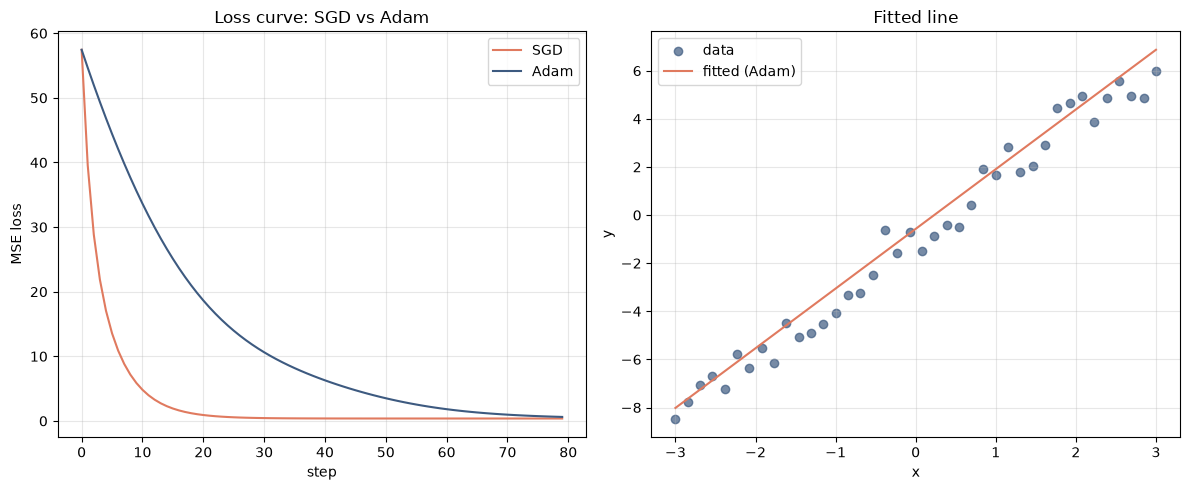

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history_sgd, label="SGD", color="#e07a5f")
axes[0].plot(history_adam, label="Adam", color="#3d5a80")
axes[0].set_title("Loss curve: SGD vs Adam")
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(xs, ys, color="#3d5a80", label="data", alpha=0.7)
x_line = torch.linspace(-3, 3, 100).unsqueeze(1)
axes[1].plot(x_line.numpy(), model_adam(x_line).detach().numpy(), color="#e07a5f", label="fitted (Adam)")
axes[1].set_title("Fitted line")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/assets/training_result.png", dpi=150)
plt.show()

## 5. 정리

- `loss.backward()`는 순전파에서 만들어진 계산 그래프를 거꾸로 타고 올라가며
  `w`, `b` 각각에 대한 기울기를 누적한다 — `torchviz`로 그 경로를 직접 확인했다.
- 같은 문제에서도 옵티마이저 선택에 따라 수렴 속도가 달라진다는 것을
  SGD/Adam 비교 실험으로 확인했다.

### 다음에 이어서 정리할 내용
- 신경망(여러 층) 모델로 확장
- 더 큰 데이터셋과 Train/Val/Test 분리
- 분류(Classification) 문제

---
*이 노트북은 [HongLab AI](https://www.honglab.ai/) 강의를 학습한 뒤 직접 재구성한
개인 학습 포트폴리오입니다. 강의 원본 코드가 아닌, 스스로 다시 작성한 코드입니다.*